In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [3]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as transforms
import torchvision.io as tv_io

import glob
import json
from PIL import Image

import utils

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

In [ ]:
from torchvision.models import vgg16
from torchvision.models import VGG16_Weights

weights = VGG16_Weights.DEFAULT
vgg_model = vgg16(weights=weights)

In [6]:
vgg_model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [7]:
vgg_model.requires_grad_(False)
print("VGG16 Frozen")

VGG16 Frozen


In [8]:
N_CLASSES = 1

my_model = nn.Sequential(
    vgg_model,
    nn.Linear(1000, N_CLASSES)
)

my_model.to(device)

Sequential(
  (0): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      (16): M

In [9]:
for idx, param in enumerate(my_model.parameters()):
    print(idx, param.requires_grad)

0 False
1 False
2 False
3 False
4 False
5 False
6 False
7 False
8 False
9 False
10 False
11 False
12 False
13 False
14 False
15 False
16 False
17 False
18 False
19 False
20 False
21 False
22 False
23 False
24 False
25 False
26 False
27 False
28 False
29 False
30 False
31 False
32 True
33 True


In [10]:
vgg_model.requires_grad_(True)
print("VGG16 Unfrozen")
for idx, param in enumerate(my_model.parameters()):
    print(idx, param.requires_grad)

VGG16 Unfrozen
0 True
1 True
2 True
3 True
4 True
5 True
6 True
7 True
8 True
9 True
10 True
11 True
12 True
13 True
14 True
15 True
16 True
17 True
18 True
19 True
20 True
21 True
22 True
23 True
24 True
25 True
26 True
27 True
28 True
29 True
30 True
31 True
32 True
33 True


In [11]:
vgg_model.requires_grad_(False)
print("VGG16 Frozen")

VGG16 Frozen


In [12]:
loss_function = nn.BCEWithLogitsLoss()
optimizer = Adam(my_model.parameters())
my_model = my_model.to(device)

In [13]:
pre_trans = weights.transforms()

In [14]:
DATA_LABELS = ["bo", "not_bo"] 
    
class MyDataset(Dataset):
    def __init__(self, data_dir):
        self.imgs = []
        self.labels = []
        
        for l_idx, label in enumerate(DATA_LABELS):
            data_paths = glob.glob(data_dir + label + '/*.jpg', recursive=True)
            for path in data_paths:
                img = Image.open(path)
                self.imgs.append(pre_trans(img).to(device))
                self.labels.append(torch.tensor(l_idx).to(device).float())


    def __getitem__(self, idx):
        img = self.imgs[idx]
        label = self.labels[idx]
        return img, label

    def __len__(self):
        return len(self.imgs)

In [15]:
n = 32

train_path = "data/presidential_doggy_door/train/"
train_data = MyDataset(train_path)
train_loader = DataLoader(train_data, batch_size=n, shuffle=True)
train_N = len(train_loader.dataset)

valid_path = "data/presidential_doggy_door/valid/"
valid_data = MyDataset(valid_path)
valid_loader = DataLoader(valid_data, batch_size=n)
valid_N = len(valid_loader.dataset)

In [16]:
IMG_WIDTH, IMG_HEIGHT = (224, 224)

random_trans = transforms.Compose([
    transforms.RandomRotation(25),
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.8, 1), ratio=(1, 1)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=.2, contrast=.2, saturation=.2, hue=.2)
])

In [17]:
def get_batch_accuracy(output, y, N):
    zero_tensor = torch.tensor([0]).to(device)
    pred = torch.gt(output, zero_tensor)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [18]:
def train(model, check_grad=False):
    loss = 0
    accuracy = 0

    model.train()
    for x, y in train_loader:
        output = torch.squeeze(model(random_trans(x)))
        optimizer.zero_grad()
        batch_loss = loss_function(output, y)
        batch_loss.backward()
        optimizer.step()

        loss += batch_loss.item()
        accuracy += get_batch_accuracy(output, y, train_N)
    if check_grad:
        print('Last Gradient:')
        for param in model.parameters():
            print(param.grad)
    print('Train - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

In [19]:
train(my_model, check_grad=True)

Last Gradient:
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
tensor([[-5.6405e-02,  4.3666e-02, -8.9296e-03,  3.3781e-01,  3.3153e-01,
          1.6234e-01,  3.5357e-01,  9.9405e-03,  7.4450e-02, -1.8098e-01,
         -1.0801e-01, -9.4490e-02,  1.3128e-01, -4.6757e-02,  2.2534e-01,
         -4.6152e-02,  2.5387e-02, -1.5135e-01, -7.4728e-03,  1.1451e-01,
         -6.6938e-02, -1.6358e-01, -2.2501e-01,  9.8679e-02, -3.3174e-01,
         -7.5886e-02, -1.0236e-01,  7.3947e-02, -2.9814e-03, -1.5680e-02,
          1.3092e-01,  1.8824e-01,  1.6251e-01,  1.3538e-01, -6.8219e-02,
         -1.7957e-01, -1.2902e-02, -4.1034e-02,  4.2102e-02,  7.8731e-02,
         -9.2119e-04, -3.4169e-01, -2.5349e-01, -1.5159e-01, -2.2467e-01,
         -4.2632e-02,  4.9702e-02,  1.7272e-01, -1.1476e-01, -7.1502e-02,
          8.9588e-02,  3.1889e-01, -2.1951e-01, -4.5162e-01, -1.7957e-01,
          9

In [20]:
def validate(model):
    loss = 0
    accuracy = 0

    model.eval()
    with torch.no_grad():
        for x, y in valid_loader:
            output = torch.squeeze(model(x))

            loss += loss_function(output, y.float()).item()
            accuracy += get_batch_accuracy(output, y, valid_N)
    print('Valid - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

In [21]:
epochs = 10

for epoch in range(epochs):
    print('Epoch: {}'.format(epoch))
    train(my_model, check_grad=False)
    validate(my_model)

Epoch: 0
Train - Loss: 2.2060 Accuracy: 0.8633
Valid - Loss: 0.4114 Accuracy: 0.7333
Epoch: 1
Train - Loss: 1.9680 Accuracy: 0.8633
Valid - Loss: 0.2791 Accuracy: 0.9000
Epoch: 2
Train - Loss: 1.6727 Accuracy: 0.8417
Valid - Loss: 0.1985 Accuracy: 0.9000
Epoch: 3
Train - Loss: 1.4682 Accuracy: 0.8705
Valid - Loss: 0.1692 Accuracy: 0.9000
Epoch: 4
Train - Loss: 1.2248 Accuracy: 0.8777
Valid - Loss: 0.1739 Accuracy: 0.9333
Epoch: 5
Train - Loss: 1.3890 Accuracy: 0.8921
Valid - Loss: 0.2061 Accuracy: 0.9333
Epoch: 6
Train - Loss: 1.2537 Accuracy: 0.8921
Valid - Loss: 0.1913 Accuracy: 0.9333
Epoch: 7
Train - Loss: 0.9898 Accuracy: 0.8633
Valid - Loss: 0.1574 Accuracy: 0.9333
Epoch: 8
Train - Loss: 1.6595 Accuracy: 0.8705
Valid - Loss: 0.1283 Accuracy: 0.9667
Epoch: 9
Train - Loss: 0.8474 Accuracy: 0.9209
Valid - Loss: 0.1096 Accuracy: 0.9667


In [22]:
# Unfreeze the base model
vgg_model.requires_grad_(True)
optimizer = Adam(my_model.parameters(), lr=.000001)

In [23]:
epochs = 2

for epoch in range(epochs):
    print('Epoch: {}'.format(epoch))
    train(my_model, check_grad=False)
    validate(my_model)

Epoch: 0
Train - Loss: 1.4477 Accuracy: 0.9281
Valid - Loss: 0.1041 Accuracy: 0.9667
Epoch: 1
Train - Loss: 1.0257 Accuracy: 0.9209
Valid - Loss: 0.0986 Accuracy: 0.9667


In [24]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_image(image_path):
    image = mpimg.imread(image_path)
    plt.imshow(image)

In [25]:
def make_prediction(file_path):
    show_image(file_path)
    image = Image.open(file_path)
    image = pre_trans(image).to(device)
    image = image.unsqueeze(0)
    output = my_model(image)
    prediction = output.item()
    return prediction

-3.4706568717956543

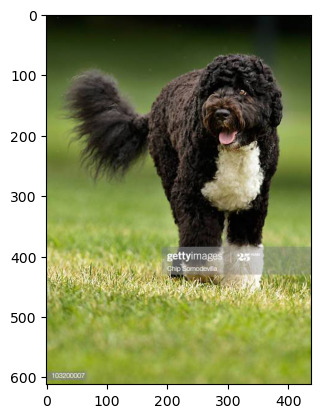

In [26]:
make_prediction('data/presidential_doggy_door/valid/bo/bo_20.jpg')

10.036027908325195

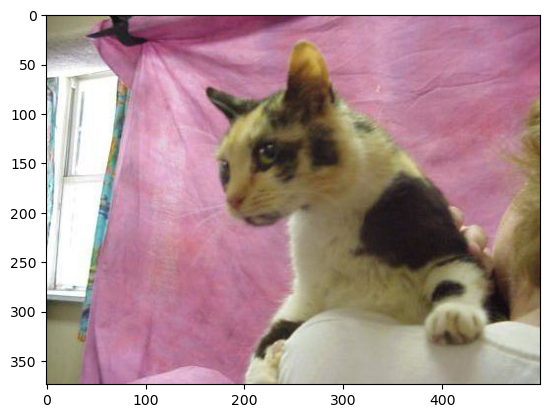

In [27]:
make_prediction('data/presidential_doggy_door/valid/not_bo/121.jpg')

In [28]:
def presidential_doggy_door(image_path):
    pred = make_prediction(image_path)
    if pred < 0:
        print("It's Bo! Let him in!")
    else:
        print("That's not Bo! Stay out!")

That's not Bo! Stay out!


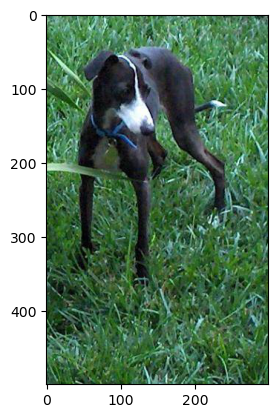

In [29]:
presidential_doggy_door('data/presidential_doggy_door/valid/not_bo/131.jpg')

It's Bo! Let him in!


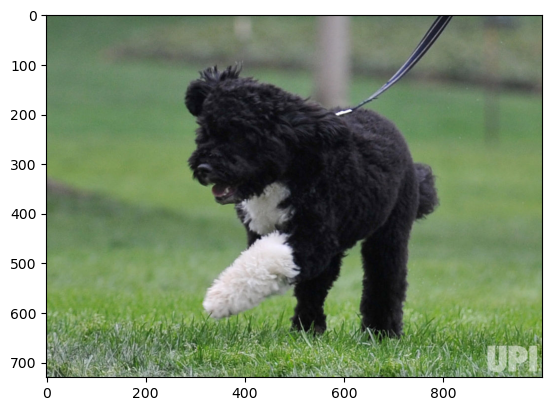

In [30]:
presidential_doggy_door('data/presidential_doggy_door/valid/bo/bo_29.jpg')